✅ Device: cuda
Loading ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s]


✅ Visual model ready!
Loading BLIP captioning model...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

✅ BLIP ready!

 Creating demo screenshot...

  BRAND AUTHENTICITY DETECTION

[1/3] Analyzing URL...
  Score         : 1.0000
  Impersonation : paypal
  Attack Type   : keyword_impersonation
  Signals       : IP=0 | BadTLD=1 | Typo=0 | Leet=1 | Keywords=3

[2/3] Visual analysis (ResNet50 + GradCAM)...
  Visual Score  : 0.5061

[3/3] BLIP image captioning...
  BLIP Caption  : the log page for the log log
  BLIP Score    : 0.0000

══════════════════════════════════════════════════════════════
  VERDICT     : 🚨 FAKE
  CONFIDENCE  : 80.08%
  BRAND       : PAYPAL (impersonated)
  ATTACK TYPE : keyword_impersonation

  Scores:
    URL Score    : 1.0000
    Visual Score : 0.5061
    BLIP Score   : 0.0000
    FINAL SCORE  : 0.8008

  📝 CAPTION:
  🚨 FAKE website detected impersonating PAYPAL (confidence: 80.1%).
Reasons: (1) URL contains brand keyword 'paypal' but is NOT the official domain | (2) TLD '.xyz' is a high-risk extension common in phishing sites | (3) 3 phishing keyword(s) found in UR

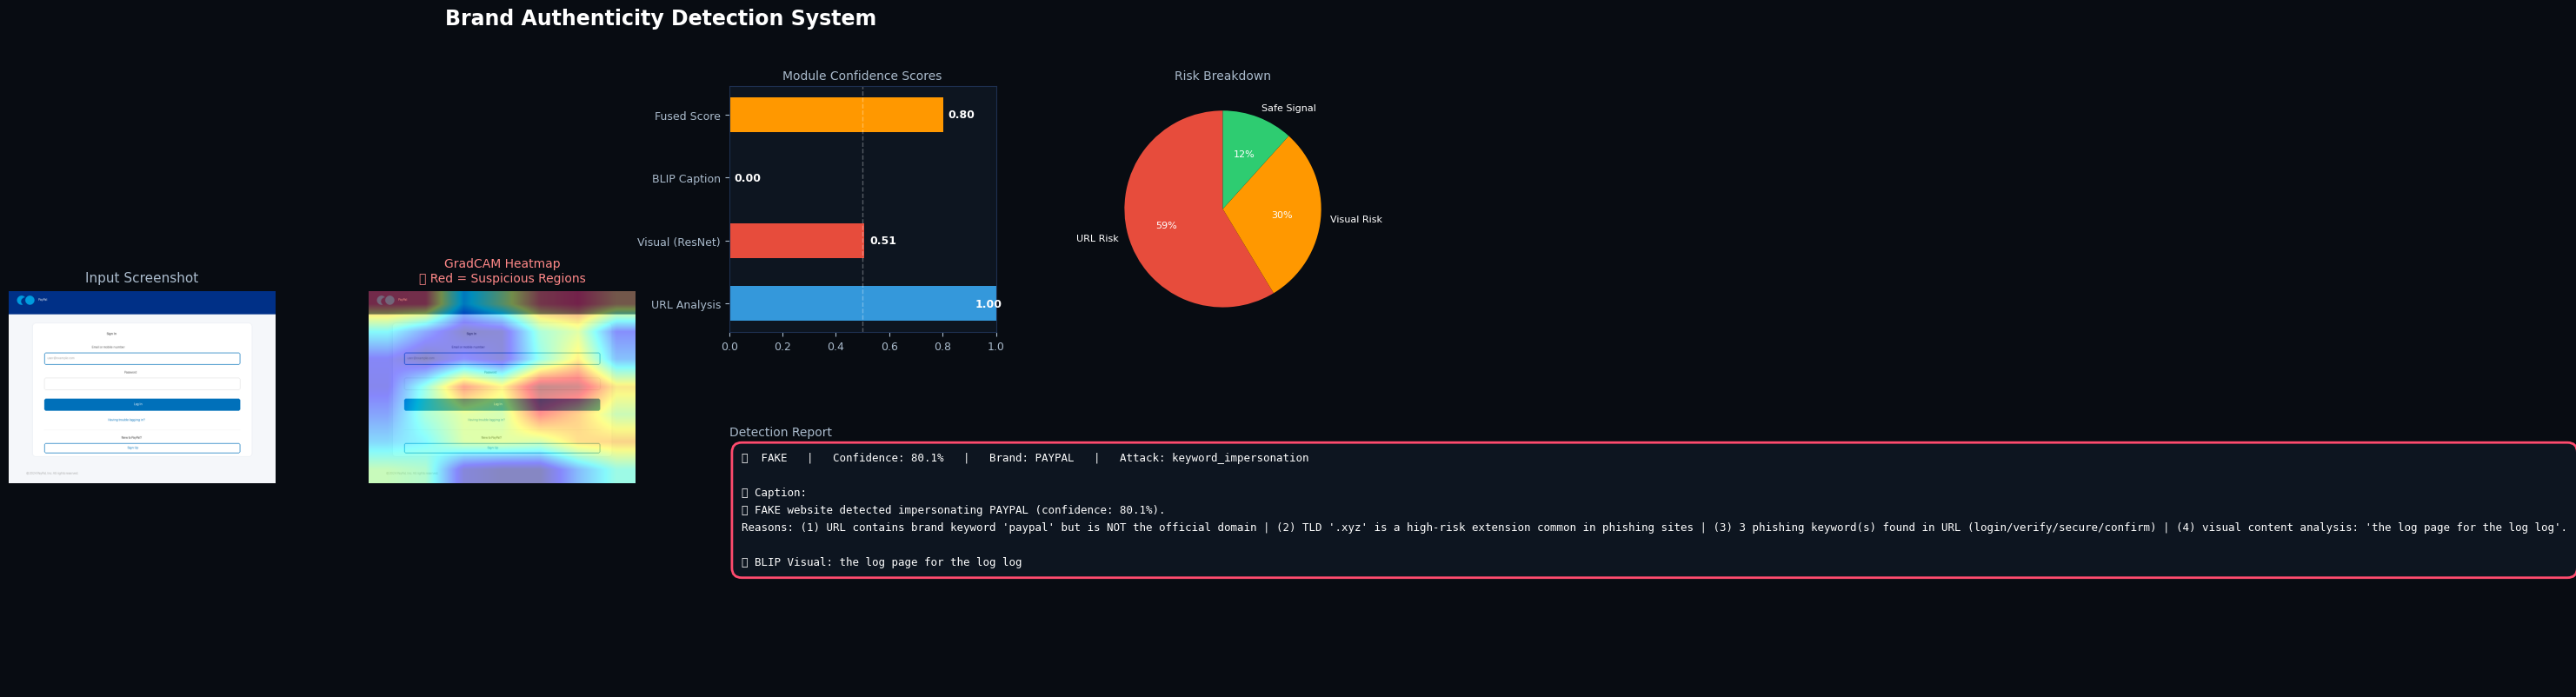


✅ Result saved → brand_detection_result.png


In [1]:
# ============================================================
#  BRAND AUTHENTICITY DETECTION SYSTEM
#  Single Cell — Copy & Paste into Google Colab
#  Input  : Screenshot + URL
#  Output : REAL/FAKE + Confidence + Brand + Caption + Heatmap
# ============================================================

# ── INSTALL ──────────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', '-q', 'editdistance', 'easyocr', 'transformers'], check=False)

# ── IMPORTS ──────────────────────────────────────────────────
import os, re, warnings, urllib.request
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image, ImageDraw, ImageFont
import cv2
import editdistance
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from transformers import BlipProcessor, BlipForConditionalGeneration
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE}")

# ── BRAND DATABASE ────────────────────────────────────────────
KNOWN_BRANDS = {
    "paypal":        {"domains": ["paypal.com"],              "keywords": ["paypal","paypai","paypa1","pay-pal","paypa"]},
    "google":        {"domains": ["google.com","gmail.com"],  "keywords": ["google","g00gle","gooogle","googie"]},
    "apple":         {"domains": ["apple.com","icloud.com"],  "keywords": ["apple","app1e","icloud","itunes","appleid"]},
    "microsoft":     {"domains": ["microsoft.com","office.com","live.com"], "keywords": ["microsoft","micr0soft","office365","mircosoft"]},
    "amazon":        {"domains": ["amazon.com"],              "keywords": ["amazon","arnazon","amaz0n","amazone"]},
    "facebook":      {"domains": ["facebook.com","fb.com"],   "keywords": ["facebook","faceb00k","face-book"]},
    "netflix":       {"domains": ["netflix.com"],             "keywords": ["netflix","netfl1x","net-flix"]},
    "chase":         {"domains": ["chase.com"],               "keywords": ["chase","chasebank","chase-bank"]},
    "wellsfargo":    {"domains": ["wellsfargo.com"],          "keywords": ["wellsfargo","wells-fargo"]},
    "bankofamerica": {"domains": ["bankofamerica.com"],       "keywords": ["bankofamerica","bofa","bank-of-america"]},
    "instagram":     {"domains": ["instagram.com"],           "keywords": ["instagram","1nstagram","instagr4m"]},
    "twitter":       {"domains": ["twitter.com","x.com"],     "keywords": ["twitter","tw1tter"]},
    "linkedin":      {"domains": ["linkedin.com"],            "keywords": ["linkedin","1inkedin"]},
    "dropbox":       {"domains": ["dropbox.com"],             "keywords": ["dropbox","dr0pbox"]},
    "dhl":           {"domains": ["dhl.com"],                 "keywords": ["dhl"]},
    "fedex":         {"domains": ["fedex.com"],               "keywords": ["fedex"]},
}

SUSPICIOUS_TLDS = {'.xyz','.tk','.ml','.ga','.cf','.gq','.top',
                   '.click','.work','.loan','.party','.date','.win','.download'}

# ── HOMOGRAPH / LEET MAPS ────────────────────────────────────
HOMOGRAPH = {'а':'a','е':'e','о':'o','р':'p','с':'c','х':'x','у':'y','і':'i','ο':'o','ρ':'p'}
LEET      = {'0':'o','1':'l','3':'e','4':'a','5':'s','@':'a','6':'g','7':'t','$':'s','8':'b'}

def normalize(t):
    for c, r in HOMOGRAPH.items(): t = t.replace(c, r)
    return t

def deleet(t):
    for d, l in LEET.items(): t = t.replace(d, l)
    return t

# ── URL ANALYZER ─────────────────────────────────────────────
def analyze_url(url):
    url_lower = url.lower().strip()
    domain    = re.sub(r'https?://', '', url_lower).split('/')[0].replace('www.', '')
    norm_dom  = normalize(domain)
    dom_name  = norm_dom.split('.')[0]
    dl_name   = deleet(dom_name)

    feats = {
        'url_length'     : len(url),
        'nb_dots'        : url.count('.'),
        'nb_hyphens'     : url.count('-'),
        'nb_digits'      : sum(c.isdigit() for c in url),
        'has_ip'         : int(bool(re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', url))),
        'has_https'      : int('https://' in url_lower),
        'has_port'       : int(bool(re.search(r':\d{2,5}(?:/|$)', url))),
        'is_shortened'   : int(any(s in url_lower for s in ['bit.ly','tinyurl','t.co','goo.gl','ow.ly'])),
        'suspicious_tld' : int(any(url_lower.endswith(t) or (t+'/' in url_lower) for t in SUSPICIOUS_TLDS)),
        'phish_keywords' : sum(k in url_lower for k in ['login','signin','verify','secure','update','account','banking','confirm','password','credential']),
        'homograph'      : int(norm_dom != domain),
        'leet_speak'     : 0,
        'typosquatting'  : 0,
        'brand_outside'  : 0,
        'impersonated_brand': None,
        'attack_type'       : None,
        'brand_confidence'  : 0.0,
    }

    # Check leet speak
    if editdistance.eval(dl_name, dom_name) > 0:
        feats['leet_speak'] = 1

    # Check brand impersonation
    for brand, info in KNOWN_BRANDS.items():
        # Skip if it IS the official domain
        if any(d in url_lower for d in info['domains']):
            continue

        # Keyword match
        for kw in info['keywords']:
            if kw in url_lower:
                feats['brand_outside']      = 1
                feats['impersonated_brand'] = brand
                feats['attack_type']        = 'keyword_impersonation'
                feats['brand_confidence']   = 0.85
                break

        if feats['impersonated_brand']:
            break

        # Typosquatting (Levenshtein ≤ 2)
        for d in info['domains']:
            official = d.split('.')[0]
            dist = editdistance.eval(dom_name, official)
            if 0 < dist <= 2:
                feats['typosquatting']      = 1
                feats['impersonated_brand'] = brand
                feats['attack_type']        = 'typosquatting'
                feats['brand_confidence']   = round(1 - dist / (len(official) + 1), 2)
                break

        if feats['impersonated_brand']:
            break

        # Leet-speak brand match
        if editdistance.eval(dl_name, brand) <= 1 and dl_name != brand:
            feats['leet_speak']         = 1
            feats['impersonated_brand'] = brand
            feats['attack_type']        = 'leet_speak'
            feats['brand_confidence']   = 0.90
            break

    # Compute final URL phishing score
    score = 0.0
    score += feats['has_ip']           * 0.35
    score += feats['suspicious_tld']   * 0.30
    score += feats['homograph']        * 0.35
    score += feats['typosquatting']    * 0.35
    score += feats['leet_speak']       * 0.30
    score += feats['brand_outside']    * 0.40
    score += feats['brand_confidence'] * 0.25
    score += min(feats['phish_keywords'] * 0.08, 0.25)
    score += feats['is_shortened']     * 0.15
    score += feats['has_port']         * 0.10
    feats['url_score'] = round(min(score, 1.0), 4)
    return feats

# ── VISUAL MODEL (ResNet50 + GradCAM) ────────────────────────
class VisualDetector(nn.Module):
    def __init__(self):
        super().__init__()
        base        = models.resnet50(pretrained=True)
        ch          = list(base.children())
        self.early  = nn.Sequential(*ch[:7])
        self.layer4 = ch[7]
        self.pool   = ch[8]
        self.head   = nn.Sequential(
            nn.Flatten(),
            nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(512, 128),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
        self._grads = None
        self._acts  = None
        self.layer4.register_forward_hook(lambda m,i,o: setattr(self,'_acts',o))
        self.layer4.register_full_backward_hook(lambda m,gi,go: setattr(self,'_grads',go[0]))

    def forward(self, x):
        x = self.early(x)
        x = self.layer4(x)
        x = self.pool(x)
        return self.head(x)

    def gradcam(self, img_tensor):
        self.eval()
        x   = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
        out = self(x)
        self.zero_grad()
        out[0, 1].backward()
        w   = self._grads[0].mean(dim=(1, 2))
        cam = F.relu((w[:, None, None] * self._acts[0]).sum(0))
        cam = cam.detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

IMG_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

print("Loading ResNet50...")
visual_model = VisualDetector().to(DEVICE)
visual_model.eval()
print("✅ Visual model ready!")

# ── BLIP CAPTIONING ───────────────────────────────────────────
print("Loading BLIP captioning model...")
blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model     = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base").to(DEVICE)
blip_model.eval()
print("✅ BLIP ready!")

@torch.no_grad()
def blip_caption(image):
    inputs = blip_processor(images=image, return_tensors="pt").to(DEVICE)
    out    = blip_model.generate(**inputs, max_new_tokens=60)
    return blip_processor.decode(out[0], skip_special_tokens=True)

# ── CAPTION GENERATOR ─────────────────────────────────────────
def generate_caption(result):
    verdict   = result.get('verdict', '?')
    brand     = result.get('impersonated_brand')
    conf      = result.get('confidence', 0)
    attack    = result.get('attack_type')
    feats     = result.get('url_features', {})
    url       = result.get('url', '')
    vis_score = result.get('visual_score', 0)
    blip_cap  = result.get('blip_caption', '')

    if verdict == 'REAL':
        cap = (f"✅ This website appears LEGITIMATE (confidence: {conf:.1%}). "
               f"No suspicious URL patterns, typosquatting, or impersonation attempts detected.")
        if blip_cap:
            cap += f" Visual content: {blip_cap}."
        return cap

    reasons = []

    if attack == 'typosquatting' and brand:
        dom = re.sub(r'https?://', '', url).split('/')[0]
        reasons.append(f"domain '{dom}' mimics '{brand}.com' via typosquatting (character substitution)")
    elif attack == 'leet_speak' and brand:
        reasons.append(f"domain uses leet-speak tricks (0→o, 1→l) to impersonate {brand}.com")
    elif attack == 'keyword_impersonation' and brand:
        reasons.append(f"URL contains brand keyword '{brand}' but is NOT the official domain")

    if feats.get('suspicious_tld'):
        ext = '.' + url.rsplit('.', 1)[-1].split('/')[0] if '.' in url else ''
        reasons.append(f"TLD '{ext}' is a high-risk extension common in phishing sites")

    if feats.get('has_ip'):
        reasons.append("raw IP address used instead of a legitimate domain name")

    if feats.get('phish_keywords', 0) > 0:
        reasons.append(f"{feats['phish_keywords']} phishing keyword(s) found in URL (login/verify/secure/confirm)")

    if feats.get('homograph'):
        reasons.append("Unicode lookalike characters detected in domain (homograph attack)")

    if feats.get('has_port'):
        reasons.append("non-standard port number in URL — suspicious for a legitimate site")

    if vis_score > 0.6:
        reasons.append(f"visual layout matches phishing page patterns ({vis_score:.0%} visual risk score)")

    if blip_cap:
        reasons.append(f"visual content analysis: '{blip_cap}'")

    if not reasons:
        reasons.append("multiple combined suspicious signals detected in URL and visual analysis")

    brand_str = f" impersonating {brand.upper()}" if brand else ""
    caption = (
        f"🚨 FAKE website detected{brand_str} (confidence: {conf:.1%}).\n"
        f"Reasons: " + " | ".join(f"({i+1}) {r}" for i, r in enumerate(reasons)) + "."
    )
    return caption

# ── HEATMAP OVERLAY ───────────────────────────────────────────
def make_heatmap(image, cam, alpha=0.45):
    img_np  = np.array(image.convert('RGB'))
    cam_rs  = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_rs), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = np.uint8(img_np * (1 - alpha) + heatmap * alpha)
    return Image.fromarray(overlay)

# ── RESULT VISUALIZATION ──────────────────────────────────────
def plot_result(screenshot, heatmap_img, result):
    BG, CARD = '#080c12', '#0d1520'
    v      = result['verdict']
    v_col  = '#ff4b6e' if v == 'FAKE' else '#00e5ff'
    v_sym  = '🚨  FAKE' if v == 'FAKE' else '✅  REAL'

    fig = plt.figure(figsize=(20, 9), facecolor=BG)
    fig.suptitle('Brand Authenticity Detection System', color='white',
                 fontsize=17, fontweight='bold', y=0.98)
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

    ax_orig  = fig.add_subplot(gs[:, 0])
    ax_heat  = fig.add_subplot(gs[:, 1])
    ax_score = fig.add_subplot(gs[0, 2])
    ax_pie   = fig.add_subplot(gs[0, 3])
    ax_cap   = fig.add_subplot(gs[1, 2:])

    for ax in [ax_orig, ax_heat, ax_score, ax_pie, ax_cap]:
        ax.set_facecolor(CARD)

    # Original screenshot
    ax_orig.imshow(screenshot); ax_orig.axis('off')
    ax_orig.set_title('Input Screenshot', color='#aabbcc', fontsize=11, pad=8)
    ax_orig.patch.set_edgecolor(v_col); ax_orig.patch.set_linewidth(2)

    # Heatmap
    ax_heat.imshow(heatmap_img); ax_heat.axis('off')
    ax_heat.set_title('GradCAM Heatmap\n🔴 Red = Suspicious Regions', color='#ff8888', fontsize=10, pad=8)

    # Score bars
    scores  = {
        'URL Analysis'  : result.get('url_score', 0),
        'Visual (ResNet)': result.get('visual_score', 0),
        'BLIP Caption'  : result.get('blip_score', 0),
        'Fused Score'   : result.get('confidence', 0),
    }
    bar_colors = ['#3498db', '#e74c3c', '#a259ff', '#ff9800']
    bars = ax_score.barh(list(scores.keys()), list(scores.values()),
                         color=bar_colors, height=0.55)
    ax_score.set_xlim(0, 1.0)
    ax_score.axvline(0.5, color='white', linestyle='--', alpha=0.3, lw=1)
    ax_score.set_title('Module Confidence Scores', color='#aabbcc', fontsize=10)
    ax_score.tick_params(colors='#aabbcc', labelsize=9)
    for sp in ax_score.spines.values(): sp.set_color('#1e3050')
    for bar, val in zip(bars, scores.values()):
        ax_score.text(min(val + 0.02, 0.92), bar.get_y() + bar.get_height() / 2,
                      f'{val:.2f}', va='center', color='white', fontsize=9, fontweight='bold')

    # Pie chart
    pie_vals   = [result.get('url_score', 0), result.get('visual_score', 0),
                  max(1 - result.get('confidence', 0), 0.01)]
    pie_labels = ['URL Risk', 'Visual Risk', 'Safe Signal']
    pie_colors = ['#e74c3c', '#ff9800', '#2ecc71']
    wedges, texts, autotexts = ax_pie.pie(
        pie_vals, labels=pie_labels, colors=pie_colors,
        autopct='%1.0f%%', startangle=90,
        textprops={'color': 'white', 'fontsize': 8}
    )
    for at in autotexts: at.set_color('white'); at.set_fontsize(8)
    ax_pie.set_title('Risk Breakdown', color='#aabbcc', fontsize=10)

    # Caption box
    caption   = result.get('caption', '')
    brand     = result.get('impersonated_brand') or 'None'
    attack    = result.get('attack_type') or '—'
    blip_c    = result.get('blip_caption', '—')
    summary   = (
        f"{v_sym}   |   Confidence: {result['confidence']:.1%}   |   "
        f"Brand: {brand.upper() if brand != 'None' else 'None'}   |   Attack: {attack}\n\n"
        f"📝 Caption:\n{caption}\n\n"
        f"🔍 BLIP Visual: {blip_c}"
    )
    ax_cap.text(0.02, 0.96, summary, transform=ax_cap.transAxes,
                va='top', ha='left', color='white', fontsize=9,
                linespacing=1.7, fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.9', facecolor=CARD,
                          edgecolor=v_col, lw=2))
    ax_cap.set_title('Detection Report', color='#aabbcc', fontsize=10, loc='left')
    ax_cap.axis('off')

    plt.savefig('brand_detection_result.png', dpi=150,
                bbox_inches='tight', facecolor=BG)
    plt.show()
    print("\n✅ Result saved → brand_detection_result.png")

# ══════════════════════════════════════════════════════════════
#  MAIN FUNCTION — detect_brand()
# ══════════════════════════════════════════════════════════════
def detect_brand(screenshot=None, url=None):
    """
    Run full brand authenticity detection.

    Args:
        screenshot : PIL.Image  — webpage screenshot (optional)
        url        : str        — URL to check (optional)

    Returns:
        dict — full detection result
    """
    print("\n" + "="*62)
    print("  BRAND AUTHENTICITY DETECTION")
    print("="*62)

    result = {
        'verdict': 'UNKNOWN', 'confidence': 0.0,
        'impersonated_brand': None, 'attack_type': None,
        'url_score': 0.0, 'visual_score': 0.0,
        'blip_score': 0.0, 'blip_caption': '',
        'url_features': {}, 'caption': '', 'url': url or '',
    }

    all_scores  = []
    brand_votes = []
    cam_img     = None

    # ── 1. URL Analysis ───────────────────────────────────
    if url:
        print("\n[1/3] Analyzing URL...")
        feats = analyze_url(url)
        score = feats['url_score']
        result['url_features'] = feats
        result['url_score']    = score
        all_scores.append(score)

        if feats['impersonated_brand']:
            brand_votes.append(feats['impersonated_brand'])
            result['attack_type'] = feats['attack_type']

        print(f"  Score         : {score:.4f}")
        print(f"  Impersonation : {feats['impersonated_brand'] or '—'}")
        print(f"  Attack Type   : {feats['attack_type'] or '—'}")
        print(f"  Signals       : IP={feats['has_ip']} | BadTLD={feats['suspicious_tld']} | "
              f"Typo={feats['typosquatting']} | Leet={feats['leet_speak']} | "
              f"Keywords={feats['phish_keywords']}")

    # ── 2. Visual Analysis ───────────────────────────────
    if screenshot is not None:
        print("\n[2/3] Visual analysis (ResNet50 + GradCAM)...")
        img_t = IMG_TF(screenshot.convert('RGB'))

        with torch.no_grad():
            out       = visual_model(img_t.unsqueeze(0).to(DEVICE))
            vis_score = float(F.softmax(out, dim=1)[0][1])

        result['visual_score'] = vis_score
        all_scores.append(vis_score)

        cam     = visual_model.gradcam(img_t)
        cam_img = make_heatmap(screenshot, cam)
        print(f"  Visual Score  : {vis_score:.4f}")

        print("\n[3/3] BLIP image captioning...")
        bc = blip_caption(screenshot)
        result['blip_caption'] = bc

        phish_words = ['login','password','verify','account','credit card','banking','secure','confirm']
        blip_score  = min(sum(w in bc.lower() for w in phish_words) * 0.2, 1.0)
        result['blip_score'] = blip_score
        all_scores.append(blip_score)
        print(f"  BLIP Caption  : {bc}")
        print(f"  BLIP Score    : {blip_score:.4f}")

    else:
        print("\n[3/3] No screenshot provided — skipping visual & BLIP.")

    # ── 3. Fusion ─────────────────────────────────────────
    if all_scores:
        final = np.mean(all_scores) * 0.4 + max(all_scores) * 0.6
    else:
        final = 0.0

    result['confidence']         = round(float(final), 4)
    result['verdict']            = 'FAKE' if final > 0.5 else 'REAL'
    result['impersonated_brand'] = (Counter(brand_votes).most_common(1)[0][0]
                                    if brand_votes else None)
    result['caption'] = generate_caption(result)

    # ── 4. Print Summary ─────────────────────────────────
    v    = result['verdict']
    flag = "🚨 FAKE" if v == 'FAKE' else "✅ REAL"
    print("\n" + "═"*62)
    print(f"  VERDICT     : {flag}")
    print(f"  CONFIDENCE  : {result['confidence']:.2%}")
    if result['impersonated_brand']:
        print(f"  BRAND       : {result['impersonated_brand'].upper()} (impersonated)")
        print(f"  ATTACK TYPE : {result['attack_type']}")
    print(f"\n  Scores:")
    print(f"    URL Score    : {result['url_score']:.4f}")
    print(f"    Visual Score : {result['visual_score']:.4f}")
    print(f"    BLIP Score   : {result['blip_score']:.4f}")
    print(f"    FINAL SCORE  : {result['confidence']:.4f}")
    print(f"\n  📝 CAPTION:\n  {result['caption']}")
    print("═"*62)

    # ── 5. Plot ───────────────────────────────────────────
    if screenshot is not None:
        plot_result(screenshot, cam_img or screenshot, result)

    return result


# ══════════════════════════════════════════════════════════════
#  DEMO — Creates a fake PayPal page & tests it
# ══════════════════════════════════════════════════════════════
print("\n Creating demo screenshot...")

# Build a fake "PayPal" phishing page
W, H   = 900, 650
canvas = Image.new('RGB', (W, H), '#f5f7fa')
draw   = ImageDraw.Draw(canvas)

# Header bar
draw.rectangle([0, 0, W, 80], fill='#003087')
draw.ellipse([28, 18, 58, 48], fill='#009cde')
draw.ellipse([42, 24, 68, 50], fill='#003087')
draw.ellipse([56, 18, 86, 48], fill='#009cde')
draw.text((100, 25), "PayPal", fill='white')

# Card
draw.rounded_rectangle([80, 110, W-80, 560], radius=12, fill='white',
                        outline='#dde3ec', width=1)
draw.text((W//2 - 120, 140), "Sign In",              fill='#1c1c1c')
draw.text((W//2 - 170, 185), "Email or mobile number",fill='#555')
draw.rounded_rectangle([120, 210, W-120, 250], radius=6,
                        fill='white', outline='#0070ba', width=2)
draw.text((130, 222), "user@example.com",             fill='#aaa')
draw.text((W//2 - 60, 270), "Password",               fill='#555')
draw.rounded_rectangle([120, 295, W-120, 335], radius=6,
                        fill='white', outline='#ccc', width=1)
draw.rounded_rectangle([120, 365, W-120, 405], radius=6, fill='#0070ba')
draw.text((W//2 - 28, 377), "Log In", fill='white')
draw.text((W//2 - 115, 430), "Having trouble logging in?", fill='#0070ba')
draw.line([120, 470, W-120, 470], fill='#eee', width=1)
draw.text((W//2 - 70, 490), "New to PayPal?",          fill='#333')
draw.rounded_rectangle([120, 515, W-120, 548], radius=6,
                        fill='white', outline='#0070ba', width=2)
draw.text((W//2 - 50, 524), "Sign Up", fill='#0070ba')
draw.text((60, 610), "© 2024 PayPal, Inc. All rights reserved.", fill='#aaa')

# ── Run Detection ──────────────────────────────────────────
result = detect_brand(
    screenshot = canvas,
    url        = "https://paypa1-secure-login.xyz/signin",
)

# ══════════════════════════════════════════════════════════════
#  TEST YOUR OWN — Just call detect_brand() with your inputs
# ══════════════════════════════════════════════════════════════
#
#  URL only:
#    result = detect_brand(url="https://g00gle-verify.tk/account")
#
#  Screenshot only:
#    from PIL import Image
#    img = Image.open("your_screenshot.png")
#    result = detect_brand(screenshot=img)
#
#  Both together:
#    result = detect_brand(screenshot=img, url="https://suspicious-url.xyz")
#
# ══════════════════════════════════════════════════════════════


  BRAND AUTHENTICITY DETECTION

[1/3] Analyzing URL...
  Score         : 0.0000
  Impersonation : —
  Attack Type   : —
  Signals       : IP=0 | BadTLD=0 | Typo=0 | Leet=0 | Keywords=0

[2/3] Visual analysis (ResNet50 + GradCAM)...
  Visual Score  : 0.5021

[3/3] BLIP image captioning...
  BLIP Caption  : eid collection by blushpec
  BLIP Score    : 0.0000

══════════════════════════════════════════════════════════════
  VERDICT     : ✅ REAL
  CONFIDENCE  : 36.82%

  Scores:
    URL Score    : 0.0000
    Visual Score : 0.5021
    BLIP Score   : 0.0000
    FINAL SCORE  : 0.3682

  📝 CAPTION:
  ✅ This website appears LEGITIMATE (confidence: 36.8%). No suspicious URL patterns, typosquatting, or impersonation attempts detected. Visual content: eid collection by blushpec.
══════════════════════════════════════════════════════════════


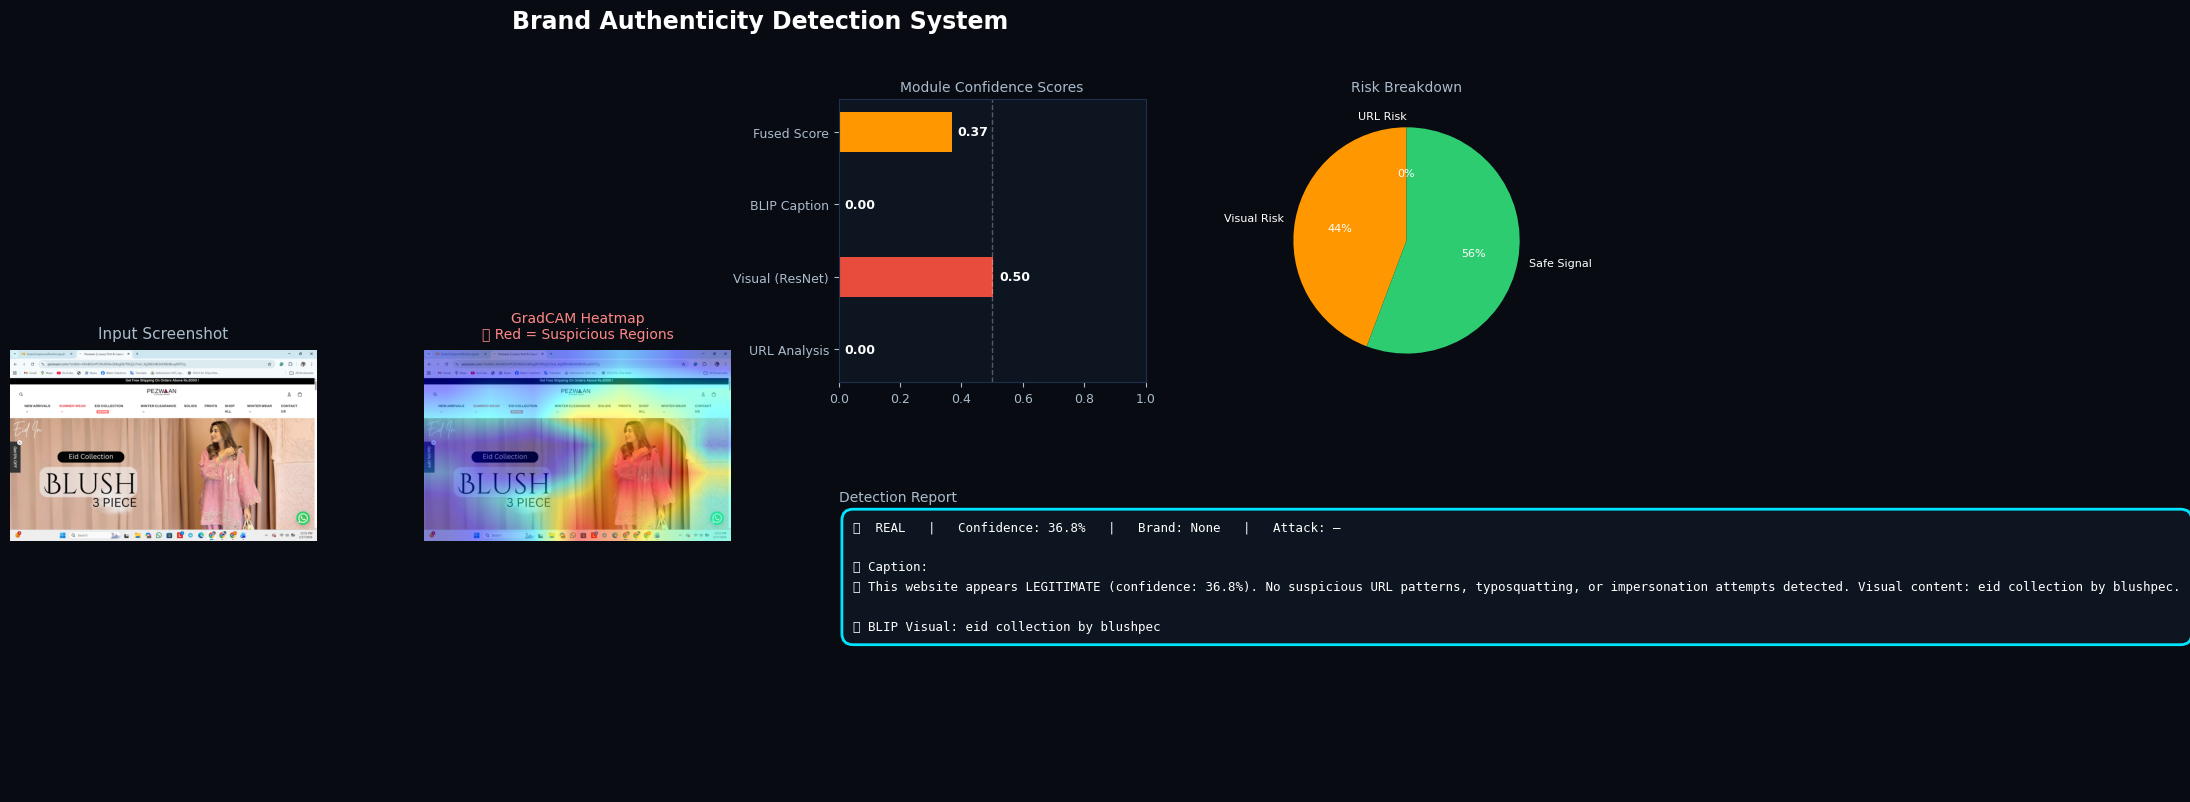


✅ Result saved → brand_detection_result.png


In [2]:
# URL only
#result = detect_brand(url="https://g00gle-verify.tk/account")

# Screenshot + URL
from PIL import Image
img = Image.open("/content/Screenshot (144).png")
result = detect_brand(screenshot=img, url="https://pezwaan.com/?srsltid=AfmBOorPCIKU6D6v2k8sg0EJTRUj2z7wU_Kg5BDnBO43XBnBsuyK0T2q")